#  Local Binary Patterns (LBP)
### Xử Lý Ảnh Số - Minh họa từng bước

---

| Cấu hình | P | R | Cách tính kết quả |
|:---:|:---:|:---:|:---:|
| 1 | 8 | 1 | $V_1$ |
| 2 | 8 | 2 | $V_1$ |
| 3 | 16 | 2 | $\max(V_1, V_2)$ |
| 4 | 16 | 3 | $\max(V_1, V_2)$ |
| 5 | 24 | 3 | $\max(V_1, V_2, V_3)$ |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

---
##  Bước 1 - Nhập ảnh và chuyển sang ảnh xám

**Công thức chuyển đổi (ITU-R BT.601):**
$$\text{Gray} = 0.299 \times R + 0.587 \times G + 0.114 \times B$$

 Kích thước : 685 x 472 pixels
 Ảnh gốc   : RGB (3 kênh)
Ảnh xám   : giá trị trong [0, 255]


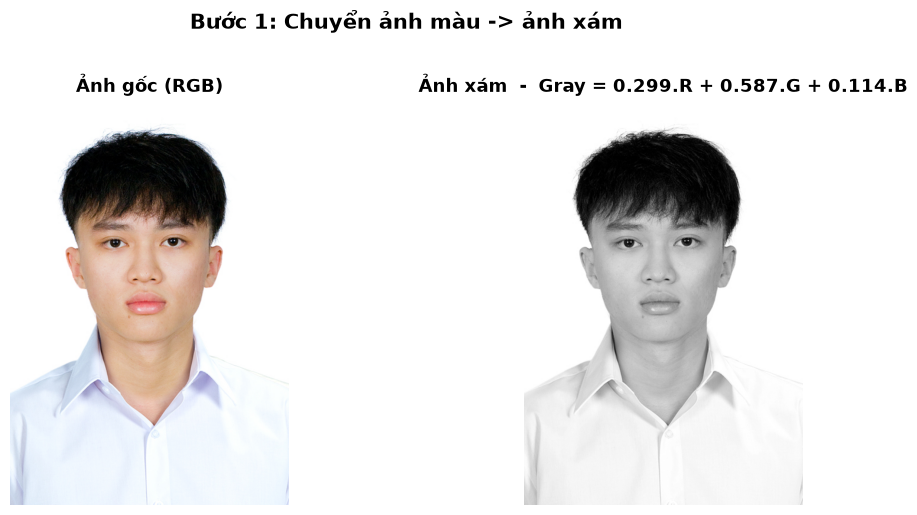

In [2]:
# -----------------------------------------
# |  NHẬP ĐƯỜNG DẪN ẢNH CỦA BẠN VÀO ĐÂY   |
# -----------------------------------------
IMAGE_PATH = r'anh_lbp.jpg'   

# -- Đọc ảnh --------------------------------------------------
img_pil  = Image.open(IMAGE_PATH).convert('RGB')
img_rgb  = np.array(img_pil, dtype=np.float64)

# -- Chuyển sang ảnh xám --------------------------------------
R_ch, G_ch, B_ch = img_rgb[:,:,0], img_rgb[:,:,1], img_rgb[:,:,2]
img_gray = 0.299*R_ch + 0.587*G_ch + 0.114*B_ch

# -- Thông tin -------------------------------------------------
H, W = img_gray.shape
print(f' Kích thước : {H} x {W} pixels')
print(f' Ảnh gốc   : RGB (3 kênh)')
print(f'Ảnh xám   : giá trị trong [{img_gray.min():.0f}, {img_gray.max():.0f}]')

# -- Hiển thị -------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img_rgb.astype(np.uint8))
axes[0].set_title('Ảnh gốc (RGB)', fontsize=13, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Ảnh xám  -  Gray = 0.299.R + 0.587.G + 0.114.B', fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.suptitle('Bước 1: Chuyển ảnh màu -> ảnh xám', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
##  Bước 2 - Tính tọa độ P điểm lan cận trên vòng tròn R

Điểm lan cận thứ $p$ được xác định bằng:

$$x_p = cx + R \cdot \cos\!\left(\frac{2\pi p}{P}\right) \qquad y_p = cy - R \cdot \sin\!\left(\frac{2\pi p}{P}\right)$$

> **Lưu ý:** Dấu **trừ** ở $y_p$ vì trục Y trong ảnh đi từ **trên xuống dưới**.

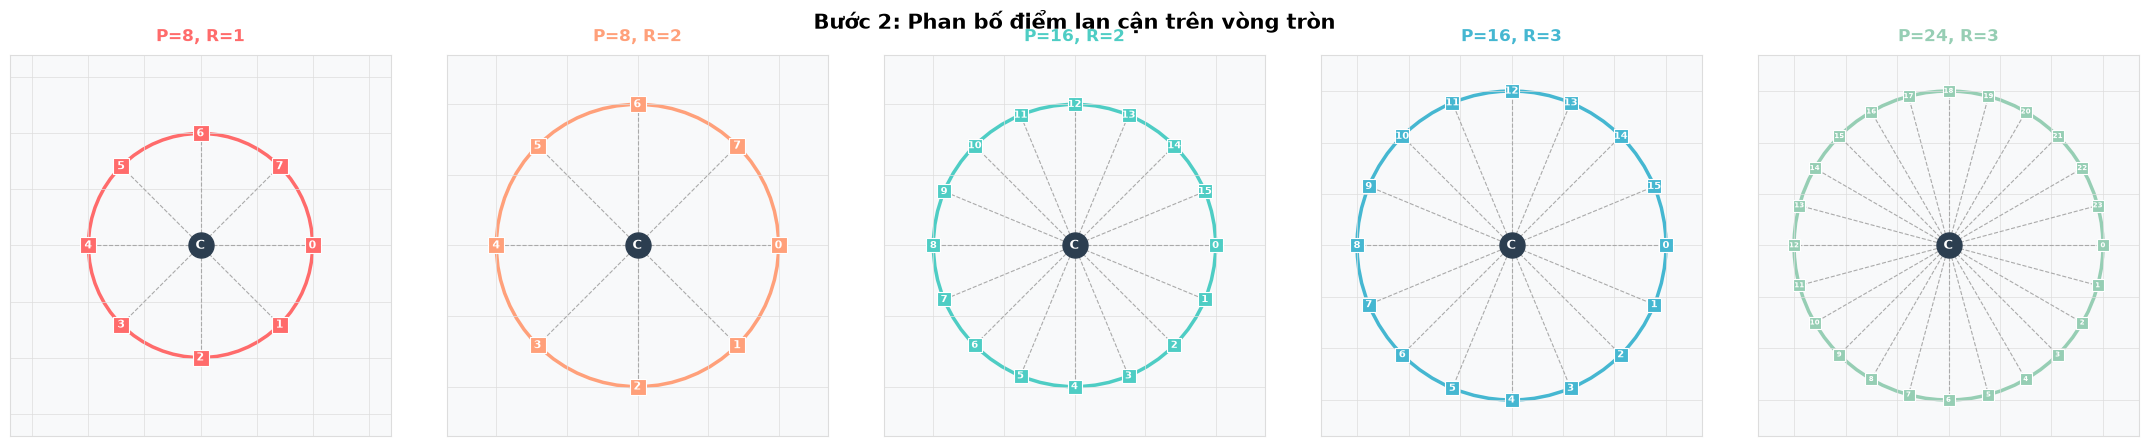

In [3]:
def tinh_toa_do_lan_can(cy, cx, P, R):
    """Tính tọa độ P điểm lan cận trên vòng tròn bán kính R."""
    coords = []
    for p in range(P):
        goc = 2 * np.pi * p / P
        xp  = cx + R * np.cos(goc)
        yp  = cy - R * np.sin(goc)
        coords.append((xp, yp))
    return coords

# -- Vẽ minh họa 5 cấu hình ------------------------------------
cau_hinh = [(8,1,'P=8, R=1'),(8,2,'P=8, R=2'),(16,2,'P=16, R=2'),
            (16,3,'P=16, R=3'),(24,3,'P=24, R=3')]
mau_sac  = ['#FF6B6B','#FFA07A','#4ECDC4','#45B7D1','#96CEB4']

fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
fig.suptitle('Bước 2: Phan bố điểm lan cận trên vòng tròn', fontsize=15, fontweight='bold')

for ax, (P, R, tieu_de), mau in zip(axes, cau_hinh, mau_sac):
    ax.set_aspect('equal')
    bien = R + 0.7
    ax.set_xlim(-bien, bien)
    ax.set_ylim(-bien, bien)
    ax.set_facecolor('#F8F9FA')

    # Vẽ vòng tròn
    vong_tron = plt.Circle((0,0), R, color=mau, fill=False, linewidth=2.5)
    ax.add_patch(vong_tron)

    # Pixel trung tam
    ax.plot(0, 0, 'o', color='#2C3E50', markersize=18, zorder=5)
    ax.text(0, 0, 'C', ha='center', va='center', fontsize=9,
            color='white', fontweight='bold', zorder=6)

    # Các điểm lan cận
    co_chu = max(5, 9 - P//6)
    for p in range(P):
        goc = 2 * np.pi * p / P
        xp  =  R * np.cos(goc)
        yp  = -R * np.sin(goc)
        ax.plot([0, xp], [0, yp], '--', color='#AAAAAA', linewidth=0.8)
        ax.plot(xp, yp, 's', color=mau, markersize=max(8,12-P//6),
                markeredgecolor='white', markeredgewidth=0.8, zorder=5)
        ax.text(xp, yp, str(p), ha='center', va='center',
                fontsize=co_chu, color='white', fontweight='bold', zorder=6)

    ax.set_title(tieu_de, fontsize=12, fontweight='bold', color=mau, pad=10)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_edgecolor('#DDDDDD')
    ax.grid(True, color='#DDDDDD', linewidth=0.5)

plt.tight_layout()
plt.show()

---
##  Bước 3 - Nội suy song tuyến (Bilinear Interpolation)

Khi tọa độ điểm lan cận **không phải số nguyên**, ta ước lượng giá trị từ **4 pixel góc gần nhất**:

$$g_p = (1{-}dy)(1{-}dx)\cdot f_{00} \;+\; (1{-}dy)\cdot dx\cdot f_{01} \;+\; dy\cdot(1{-}dx)\cdot f_{10} \;+\; dy\cdot dx\cdot f_{11}$$

Trong đó $dx = x_p - \lfloor x_p \rfloor$, $\;dy = y_p - \lfloor y_p \rfloor$

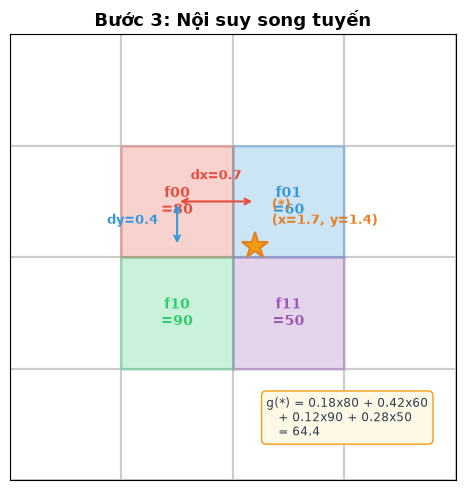

In [4]:
def noi_suy_song_tuyen(anh, y, x):
    """
    Nội suy song tuyến tại tọa độ thực (x, y).
    Ước lượng giá trị từ 4 pixel góc gần nhất.
    """
    rows, cols = anh.shape

    x0, y0 = int(np.floor(x)), int(np.floor(y))
    x1, y1 = x0 + 1, y0 + 1

    # Giữ trong biên ảnh
    x0 = np.clip(x0, 0, cols-1);  x1 = np.clip(x1, 0, cols-1)
    y0 = np.clip(y0, 0, rows-1);  y1 = np.clip(y1, 0, rows-1)

    dx = x - np.floor(x)   # phần lẻ ngang
    dy = y - np.floor(y)   # phần lẻ dọc

    f00 = anh[y0, x0]   # góc trái-trên
    f01 = anh[y0, x1]   # góc phải-trên
    f10 = anh[y1, x0]   # góc trái-dưới
    f11 = anh[y1, x1]   # góc phải-dưới

    return (1-dy)*(1-dx)*f00 + (1-dy)*dx*f01 \
         +    dy *(1-dx)*f10 +    dy *dx*f11

# -- Vẽ minh họa nội suy ---------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
ax.set_xlim(-0.5, 3.5);  ax.set_ylim(-0.5, 3.5)
ax.set_aspect('equal');  ax.invert_yaxis()
ax.set_facecolor('#F8F9FA')

# Vẽ lưới pixel
for i in range(4):
    for j in range(4):
        rect = plt.Rectangle((j-0.5, i-0.5), 1, 1,
                              fill=True, facecolor='white',
                              edgecolor='#CCCCCC', linewidth=1.5)
        ax.add_patch(rect)

# 4 pixel góc tham gia nội suy
goc_pixels = [(1,1,'f00\n=80'),(1,2,'f01\n=60'),(2,1,'f10\n=90'),(2,2,'f11\n=50')]
goc_mau    = ['#E74C3C','#3498DB','#2ECC71','#9B59B6']
for (gy, gx, label), mau in zip(goc_pixels, goc_mau):
    ax.add_patch(plt.Rectangle((gx-0.5, gy-0.5), 1, 1,
                 facecolor=mau, alpha=0.25, edgecolor=mau, linewidth=2))
    ax.text(gx, gy, label, ha='center', va='center',
            fontsize=10, fontweight='bold', color=mau)

# Điểm cần nội suy
xstar, ystar = 1.7, 1.4
dx_ex = xstar - 1;  dy_ex = ystar - 1
ax.plot(xstar, ystar, '*', color='#F39C12', markersize=20, zorder=10,
        markeredgecolor='#E67E22', markeredgewidth=1.5)
ax.text(xstar+0.15, ystar-0.2, f'(*)\n(x={xstar}, y={ystar})',
        fontsize=9, color='#E67E22', fontweight='bold')

# Mũi tên dx, dy
ax.annotate('', xy=(xstar,1), xytext=(1,1),
            arrowprops=dict(arrowstyle='<->', color='#E74C3C', lw=1.5))
ax.text((1+xstar)/2, 0.8, f'dx={dx_ex:.1f}', ha='center',
        color='#E74C3C', fontsize=9, fontweight='bold')

ax.annotate('', xy=(1,ystar), xytext=(1,1),
            arrowprops=dict(arrowstyle='<->', color='#3498DB', lw=1.5))
ax.text(0.6, (1+ystar)/2, f'dy={dy_ex:.1f}', ha='center',
        color='#3498DB', fontsize=9, fontweight='bold')

# Tính kết quả
gp_ex = (1-dy_ex)*(1-dx_ex)*80 + (1-dy_ex)*dx_ex*60 \
      +    dy_ex *(1-dx_ex)*90 +    dy_ex *dx_ex*50
ax.text(1.8, 3.1,
    f'g(*) = {(1-dy_ex)*(1-dx_ex):.2f}x80 + {(1-dy_ex)*dx_ex:.2f}x60\n'
    f'   + {dy_ex*(1-dx_ex):.2f}x90 + {dy_ex*dx_ex:.2f}x50\n'
    f'   = {gp_ex:.1f}',
    fontsize=8.5, color='#2C3E50',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#FEF9E7', edgecolor='#F39C12'))

ax.set_title('Bước 3: Nội suy song tuyến', fontsize=13, fontweight='bold')
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
plt.tight_layout()
plt.show()

---
## Bước 4, 5, 6 - Tạo chuỗi bit -> Chuyển sang số -> Tách nhóm lấy MAX

**Bước 4:** So sánh từng điểm lan cận $g_p$ với pixel trung tam $g_c$:
$$\text{bit}_p = \begin{cases} 1 & g_p \geq g_c \\ 0 & g_p < g_c \end{cases}$$

**Bước 5:** Chuyển mỗi nhóm 8-bit sang số thập phan:
$$V = \sum_{i=0}^{7} \text{bit}_i \times 2^i \in [0,\, 255]$$

**Bước 6:** Tách nhóm và lấy MAX:
- **P=8** -> 1 nhóm -> $\text{LBP} = V_1$
- **P=16** -> 2 nhóm -> $\text{LBP} = \max(V_1,\, V_2)$
- **P=24** -> 3 nhóm -> $\text{LBP} = \max(V_1,\, V_2,\, V_3)$

In [5]:
def tinh_lbp_mot_pixel(anh, cy, cx, P, R):
    """
    Tính giá trị LBP cho pixel trung tam tại (cy, cx).
    Trả về giá trị thuoc [0, 255].
    """
    gc   = anh[cy, cx]   # giá trị pixel trung tam
    bits = []             # chuỗi bit

    # -- Bước 2, 3, 4 ------------------------------------------
    for p in range(P):
        goc = 2 * np.pi * p / P
        xp  = cx + R * np.cos(goc)
        yp  = cy - R * np.sin(goc)
        gp  = noi_suy_song_tuyen(anh, yp, xp)   # Bước 3
        bits.append(1 if gp >= gc else 0)        # Bước 4

    # -- Bước 5 & 6: Tách nhóm 8-bit -> lấy MAX --------------
    so_nhom = P // 8     # P=8->1, P=16->2, P=24->3
    gia_tri_nhom = []

    for g in range(so_nhom):
        nhom = bits[g*8 : (g+1)*8]
        val  = sum(b * (2**i) for i, b in enumerate(nhom))  # bit_0 = LSB
        gia_tri_nhom.append(val)

    return max(gia_tri_nhom)   # Lấy giá trị lớn nhất


def tinh_lbp_toan_anh(anh_xam, P, R):
    """
    Áp dụng LBP lên toàn bộ ảnh xám.
    Pixel biên (trong vùng ceil(R)) được gán = 0.
    """
    rows, cols = anh_xam.shape
    anh_lbp    = np.zeros((rows, cols), dtype=np.uint8)
    bien       = int(np.ceil(R))

    for cy in range(bien, rows - bien):
        for cx in range(bien, cols - bien):
            anh_lbp[cy, cx] = tinh_lbp_mot_pixel(anh_xam, cy, cx, P, R)

    return anh_lbp

print('Đã định nghĩa các hàm LBP!')

Đã định nghĩa các hàm LBP!


---
##  Minh họa từng bước tại 1 pixel cụ thể

In [6]:
# Pixel trung tam để minh họa
cy_demo = img_gray.shape[0] // 2
cx_demo = img_gray.shape[1] // 2

print(f' Minh họa tại pixel trung tam ảnh: ({cy_demo}, {cx_demo})')
print(f'   Giá trị pixel trung tam gc = {img_gray[cy_demo, cx_demo]:.1f}')

for P, R, nhan in cau_hinh:
    gc   = img_gray[cy_demo, cx_demo]
    bits = []

    print(f'\n{"="*58}')
    print(f'  {nhan}  |  gc = {gc:.1f}')
    print(f'  {"p":>3}  {"Góc":>7}  {"(xp, yp)":>18}  {"gp":>7}  {"bit":>5}')
    print(f'  {"-"*50}')

    for p in range(P):
        goc = 2 * np.pi * p / P
        xp  = cx_demo + R * np.cos(goc)
        yp  = cy_demo - R * np.sin(goc)
        gp  = noi_suy_song_tuyen(img_gray, yp, xp)
        bit = 1 if gp >= gc else 0
        bits.append(bit)
        print(f'  {p:>3}  {np.degrees(goc):>6.1f}°  ({xp:>8.2f},{yp:>8.2f})  {gp:>7.2f}  {bit:>5}')

    so_nhom      = P // 8
    gia_tri_nhom = []
    print(f'\n  Chuỗi {P} bit: {bits}')
    for g in range(so_nhom):
        nhom = bits[g*8:(g+1)*8]
        val  = sum(b*(2**i) for i,b in enumerate(nhom))
        gia_tri_nhom.append(val)
        print(f'  Nhóm {g+1} (bit {g*8}->{g*8+7}): V{g+1} = {val}')
    print(f'  => LBP = max{gia_tri_nhom} = {max(gia_tri_nhom)}')

 Minh họa tại pixel trung tam ảnh: (342, 236)
   Giá trị pixel trung tam gc = 120.8

  P=8, R=1  |  gc = 120.8
    p      Góc            (xp, yp)       gp    bit
  --------------------------------------------------
    0     0.0°  (  237.00,  342.00)   119.16      0
    1    45.0°  (  236.71,  341.29)   113.54      0
    2    90.0°  (  236.00,  341.00)   109.15      0
    3   135.0°  (  235.29,  341.29)   111.67      0
    4   180.0°  (  235.00,  342.00)   119.03      0
    5   225.0°  (  235.29,  342.71)   122.75      1
    6   270.0°  (  236.00,  343.00)   124.08      1
    7   315.0°  (  236.71,  342.71)   124.83      1

  Chuỗi 8 bit: [0, 0, 0, 0, 0, 1, 1, 1]
  Nhóm 1 (bit 0->7): V1 = 224
  => LBP = max[224] = 224

  P=8, R=2  |  gc = 120.8
    p      Góc            (xp, yp)       gp    bit
  --------------------------------------------------
    0     0.0°  (  238.00,  342.00)   120.32      0
    1    45.0°  (  237.41,  340.59)   116.02      0
    2    90.0°  (  236.00,  340.00)  

---
##  Bước 7 - Tính LBP cho toàn bộ ảnh

> **Lưu ý:** Bước này tính từng pixel một nên sẽ mất vài phút tùy kích thước ảnh.

In [7]:
ket_qua_lbp = {}

for P, R, nhan in cau_hinh:
    print(f'Đang xử lý {nhan} ...', end='  ', flush=True)
    anh_lbp = tinh_lbp_toan_anh(img_gray, P, R)
    ket_qua_lbp[nhan] = anh_lbp
    print(f' min={anh_lbp.min():>3}, max={anh_lbp.max():>3}, mean={anh_lbp.mean():>6.1f}')

print('\n Hoàn thành tất cả 5 cấu hình!')

Đang xử lý P=8, R=1 ...   min=  0, max=255, mean= 169.5
Đang xử lý P=8, R=2 ...   min=  0, max=255, mean= 169.0
Đang xử lý P=16, R=2 ...   min=  0, max=255, mean= 200.3
Đang xử lý P=16, R=3 ...   min=  0, max=255, mean= 201.8
Đang xử lý P=24, R=3 ...   min=  0, max=255, mean= 216.9

 Hoàn thành tất cả 5 cấu hình!


---
##  Hiển thị kết quả

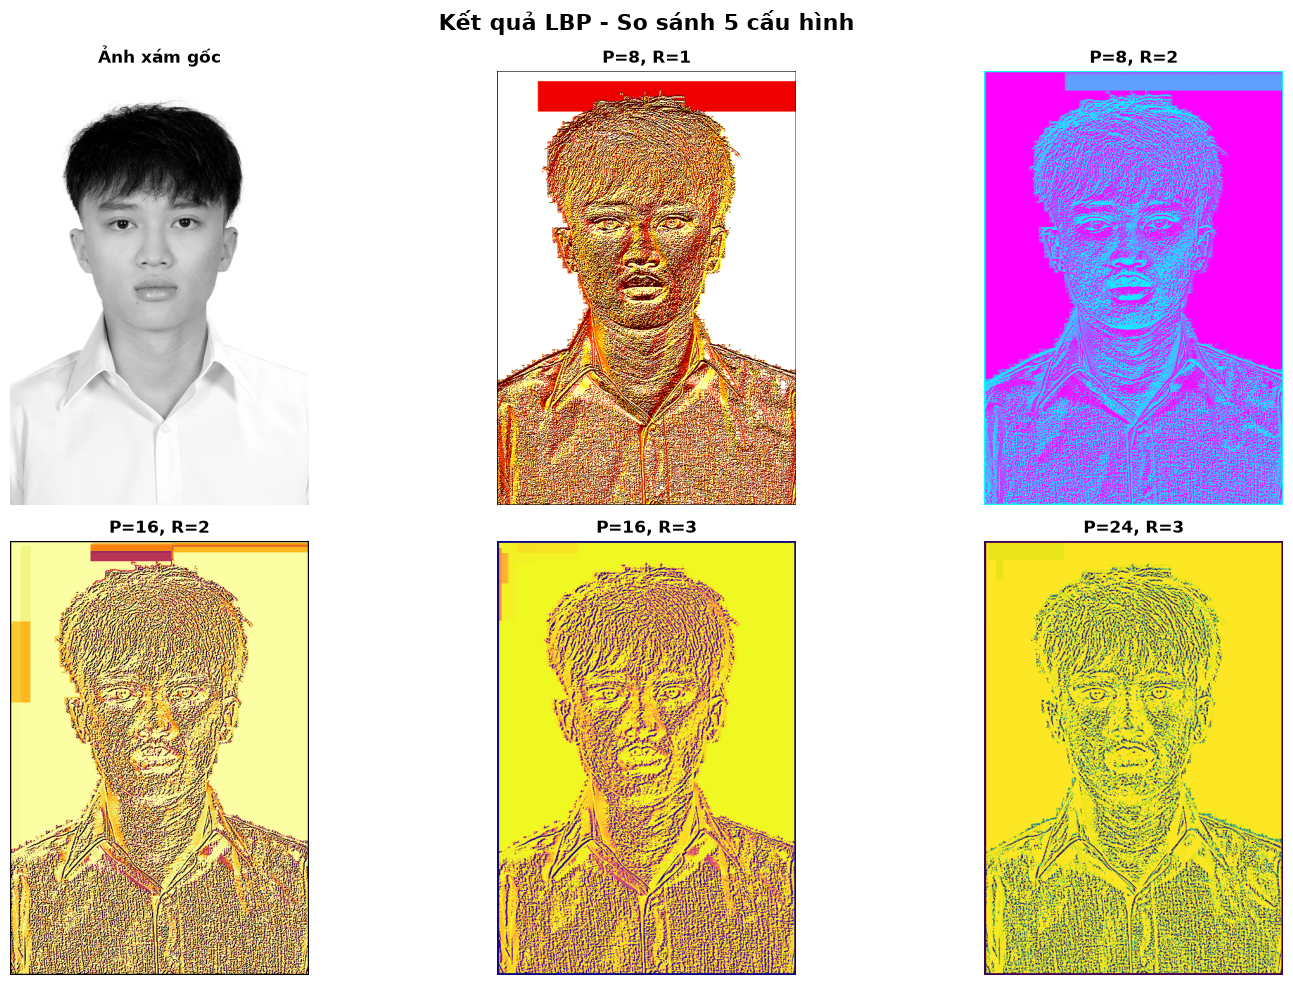

Đã lưu: LBP_anh_ket_qua.png


In [8]:
# -- Hình 1: So sánh ảnh gốc xám và 5 ảnh LBP -----------------
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Kết quả LBP - So sánh 5 cấu hình', fontsize=16, fontweight='bold')

ax_list = axes.ravel()

# Ảnh xám gốc
ax_list[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
ax_list[0].set_title('Ảnh xám gốc', fontsize=12, fontweight='bold')
ax_list[0].axis('off')

# 5 ảnh LBP
ban_do_mau = ['hot','cool','inferno','plasma','viridis']
for i, ((nhan, anh_lbp), bm) in enumerate(zip(ket_qua_lbp.items(), ban_do_mau)):
    ax = ax_list[i+1]
    ax.imshow(anh_lbp, cmap=bm, vmin=0, vmax=255)
    ax.set_title(nhan, fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('LBP_anh_ket_qua.png', dpi=150, bbox_inches='tight')
plt.show()
print('Đã lưu: LBP_anh_ket_qua.png')

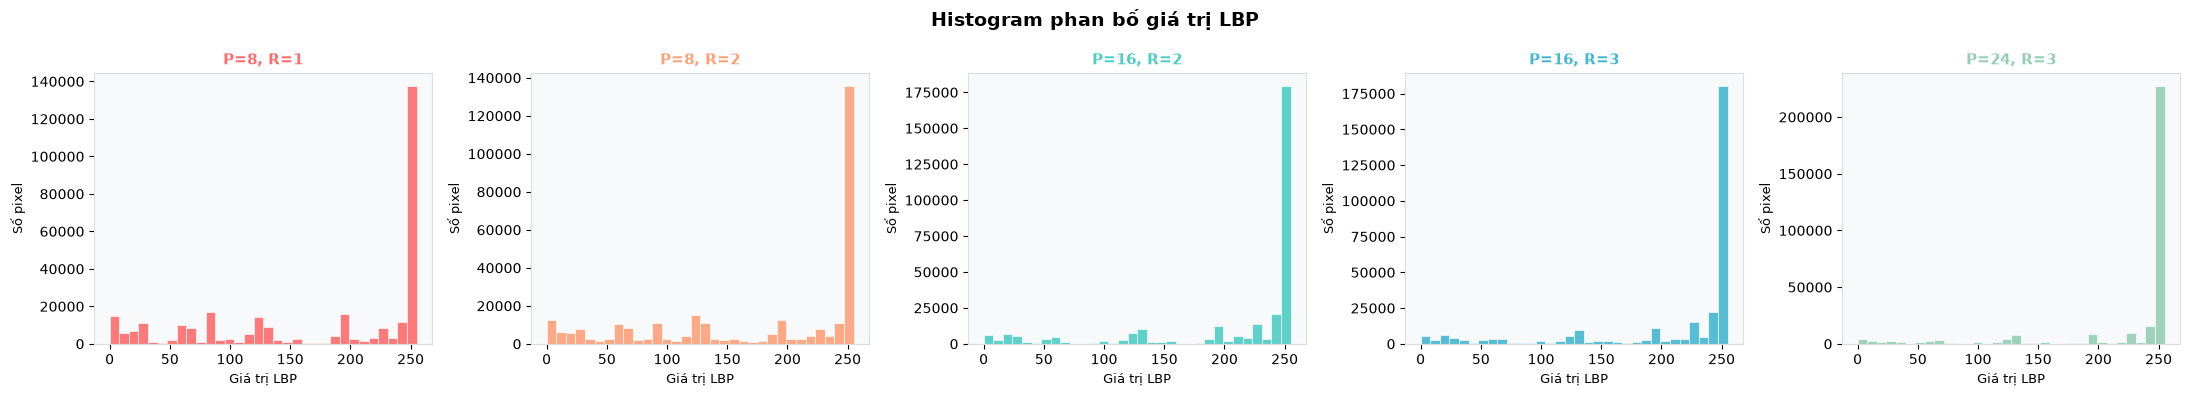

Đã lưu: LBP_histogram.png


In [9]:
# -- Hình 2: Histogram phan bố giá trị LBP ---------------------
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('Histogram phan bố giá trị LBP', fontsize=14, fontweight='bold')

for ax, ((nhan, anh_lbp), mau) in zip(axes, zip(ket_qua_lbp.items(), mau_sac)):
    pixels_hop_le = anh_lbp[anh_lbp > 0].ravel()
    ax.hist(pixels_hop_le, bins=32, range=(0,255), color=mau,
            edgecolor='white', linewidth=0.5, alpha=0.9)
    ax.set_title(nhan, fontsize=11, fontweight='bold', color=mau)
    ax.set_xlabel('Giá trị LBP', fontsize=9)
    ax.set_ylabel('Số pixel', fontsize=9)
    ax.set_facecolor('#F8F9FA')
    for spine in ax.spines.values():
        spine.set_edgecolor('#DDDDDD')

plt.tight_layout()
plt.savefig('LBP_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Đã lưu: LBP_histogram.png')

---
##  Bảng thống kê kết quả

In [10]:
print('=' * 72)
print(f'  {"Cấu hình":<14} {"Min":>5} {"Max":>5} {"Mean":>8} {"Std":>8} {"Pixel hợp lệ":>20}')
print('=' * 72)

for nhan, anh_lbp in ket_qua_lbp.items():
    hop_le = anh_lbp[anh_lbp > 0]
    phan_tram = 100 * len(hop_le) / anh_lbp.size
    print(f'  {nhan:<14} {anh_lbp.min():>5} {anh_lbp.max():>5} '
          f'{anh_lbp.mean():>8.2f} {anh_lbp.std():>8.2f} '
          f'{len(hop_le):>8}/{anh_lbp.size} ({phan_tram:.1f}%)')

print('=' * 72)
print('Ghi chú: "Pixel hợp lệ" = đã được tính LBP (không kể biên = 0)')

  Cấu hình         Min   Max     Mean      Std         Pixel hợp lệ
  P=8, R=1           0   255   169.54    95.55   308940/323320 (95.6%)
  P=8, R=2           0   255   168.97    96.02   303143/323320 (93.8%)
  P=16, R=2          0   255   200.35    85.99   305852/323320 (94.6%)
  P=16, R=3          0   255   201.78    84.57   307651/323320 (95.2%)
  P=24, R=3          0   255   216.91    77.32   307788/323320 (95.2%)
Ghi chú: "Pixel hợp lệ" = đã được tính LBP (không kể biên = 0)
